this notebook contains all steps from data cleaning to model training all in accordance for model training and evaluation for the forecast model for next hour's electricity demand

importing necessary libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb
import re

# settings
plt.style.use('default')
pd.set_option('display.max_columns', None)


loading all three datasets using pandas; and the naming convetion for datasets is-
1] demand is PCGB_date_power_demand dataset
2] econ is economic_full_1
3] weather is weather_data

In [64]:
demand = pd.read_excel("PGCB_date_power_demand.xlsx")
weather = pd.read_excel("weather_data.xlsx")
econ = pd.read_csv("economic_full_1.csv")

now that datasets are loaded, inspecting the rows, cols, description of dataset and likewise 

In [65]:
print(demand.head())
print(demand.info())
print(demand.describe())
print(demand.columns)

             datetime  generation_mw  demand_mw  load_shedding   gas  \
0 2015-04-19 22:00:00         6323.0       6323              0     0   
1 2015-04-19 21:00:00         6667.0       6667              0     0   
2 2015-04-19 19:00:00         6897.0       6897              0  4415   
3 2015-04-19 18:30:00         6933.0       6933              0  4423   
4 2015-04-19 18:00:00         6874.0       6874              0  4319   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    NaN   NaN                     0              0   
1            0     0      0    NaN   NaN                     0              0   
2         1836   161     41    NaN   NaN                   444              0   
3         1862   159     45    NaN   NaN                   444              0   
4         1892   155     65    NaN   NaN                   443              0   

   india_adani  nepal       remarks  
0          NaN    NaN           NaN  
1   

doing same for econ dataset

In [66]:
print(econ.tail())
print(econ.columns)
print(econ.info())
print(econ.describe())


     Country Name                                     Indicator Name  \
1511            X  Net bilateral aid flows from DAC donors, Total...   
1512            X  Net bilateral aid flows from DAC donors, Portu...   
1513            X  Net bilateral aid flows from DAC donors, Nethe...   
1514            X  Net bilateral aid flows from DAC donors, Japan...   
1515            X  Net bilateral aid flows from DAC donors, Hunga...   

      Indicator Code  1960  1961  1962  1963  1964  1965  1966  1967  1968  \
1511  DC.DAC.TOTL.CD   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1512  DC.DAC.PRTL.CD   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1513  DC.DAC.NLDL.CD   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1514  DC.DAC.JPNL.CD   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1515  DC.DAC.HUNL.CD   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

      1969  1970          1971          1972          1973          1974  \
1511   NaN   NaN  1.53

also for weather dataset

In [67]:
print(weather.head())
print(weather.columns)
print(weather.describe())
print(weather.info())

              latitude            longitude                 elevation  \
0              23.7961              90.3805                         9   
1                  NaN                  NaN                       NaN   
2                 time  temperature_2m (°C)  relative_humidity_2m (%)   
3  2014-01-01 00:00:00                 13.9                        89   
4  2014-01-01 01:00:00                 13.6                        91   

          utc_offset_seconds            timezone timezone_abbreviation  \
0                      21600          Asia/Dhaka                 GMT+6   
1                        NaN                 NaN                   NaN   
2  apparent_temperature (°C)  precipitation (mm)     dew_point_2m (°C)   
3                       13.3                   0                  12.1   
4                       13.2                   0                  12.1   

                       Unnamed: 6              Unnamed: 7       Unnamed: 8  \
0                             NaN     

firstly, starting from weather dataset - finding out the percentage of null values

In [68]:
weather.isnull().mean() * 100

latitude                 0.000932
longitude                0.000932
elevation                0.000932
utc_offset_seconds       0.000932
timezone                 0.000932
timezone_abbreviation    0.000932
Unnamed: 6               0.001864
Unnamed: 7               0.001864
Unnamed: 8               0.001864
Unnamed: 9               0.001864
dtype: float64

In weather dataset, the null values are almost negligible; so leaving them as it is.


However, there are four unnamed cols present.
when, weather.head() was used, the first two rows(row 0,1) were irrelevant; and the correct headers for cols where present in row 2; thus starting with weather's data curation- by renaming cols.

starting with copying the original dataset weather and working on it; now w1 is the copy of weather dataset

In [69]:
w1 = weather.copy()
w1.columns = w1.iloc[2]
w1 = w1.iloc[3:].reset_index(drop=True)
w1 = w1.rename(columns={
    'time': 'datetime',
    'temperature_2m (°C)': 'temp',
    'relative_humidity_2m (%)': 'humidity',
    'apparent_temperature (°C)': 'apparent_temp',
    'precipitation (mm)': 'precipitation',
    'dew_point_2m (°C)': 'dew_point',
    'soil_temperature_0_to_7cm (°C)': 'soil_temp',
    'wind_direction_10m (°)': 'wind_dir',
    'cloud_cover (%)': 'cloud_cover',
    'sunshine_duration (s)': 'sunshine'
})
print(w1.columns)
print(w1.head())


Index(['datetime', 'temp', 'humidity', 'apparent_temp', 'precipitation',
       'dew_point', 'soil_temp', 'wind_dir', 'cloud_cover', 'sunshine'],
      dtype='object', name=2)
2             datetime  temp humidity apparent_temp precipitation dew_point  \
0  2014-01-01 00:00:00  13.9       89          13.3             0      12.1   
1  2014-01-01 01:00:00  13.6       91          13.2             0      12.1   
2  2014-01-01 02:00:00  13.3       91          12.8             0      11.9   
3  2014-01-01 03:00:00    13       92          12.5             0      11.8   
4  2014-01-01 04:00:00  12.7       93          12.2             0      11.6   

2 soil_temp wind_dir cloud_cover sunshine  
0      16.4      313           0        0  
1        16      317           0        0  
2      15.7      317           0        0  
3      15.4      319           0        0  
4      15.2      322           0        0  


now, checking whether the datatypes are changed in the weather dataset 

In [70]:
print(w1.dtypes)

2
datetime         object
temp             object
humidity         object
apparent_temp    object
precipitation    object
dew_point        object
soil_temp        object
wind_dir         object
cloud_cover      object
sunshine         object
dtype: object


Here, the data is stored in 'OBJECT' dtype ie plain text; for further ease we are changing:
1] the existing datetime col; currently with object dtype to 'datetime objects' using pandas;
2] for other cols- using loop; convert the data(object form) to numbers either float/int.

In [71]:
w1['datetime'] = pd.to_datetime(w1['datetime'], errors='coerce')
for col in w1.columns:
    if col != 'datetime':
        w1[col] = pd.to_numeric(w1[col], errors='coerce')

w1 = w1.dropna(subset=['datetime']) 
w1 = w1.sort_values('datetime')
print(w1.dtypes)


2
datetime         datetime64[ns]
temp                    float64
humidity                  int64
apparent_temp           float64
precipitation           float64
dew_point               float64
soil_temp               float64
wind_dir                  int64
cloud_cover               int64
sunshine                float64
dtype: object


loading a few rows to check whether changes are done

In [72]:
w1.head(9)

2,datetime,temp,humidity,apparent_temp,precipitation,dew_point,soil_temp,wind_dir,cloud_cover,sunshine
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0
5,2014-01-01 05:00:00,12.4,94,11.9,0.0,11.5,14.9,324,0,0.0
6,2014-01-01 06:00:00,12.0,95,11.2,0.0,11.2,14.6,325,0,0.0
7,2014-01-01 07:00:00,11.6,96,10.8,0.0,11.0,14.3,325,0,0.0
8,2014-01-01 08:00:00,13.9,92,14.0,0.0,12.5,15.5,328,0,3600.0


checking for null values in w1 dataset

In [73]:
w1.isnull().mean() * 100

2
datetime         0.0
temp             0.0
humidity         0.0
apparent_temp    0.0
precipitation    0.0
dew_point        0.0
soil_temp        0.0
wind_dir         0.0
cloud_cover      0.0
sunshine         0.0
dtype: float64

In [74]:
w1.dtypes

2
datetime         datetime64[ns]
temp                    float64
humidity                  int64
apparent_temp           float64
precipitation           float64
dew_point               float64
soil_temp               float64
wind_dir                  int64
cloud_cover               int64
sunshine                float64
dtype: object

as the null values are zeroes and datatypes fixed too; we move to the next dataset

now, moving ahead to dataset demand.

overviewing demand dataset using head(), info(), describe(), .columns(), likewise

In [75]:
print(demand.head())
print(demand.columns)
print(demand.info())
print(demand.describe())
print(demand.dtypes)

             datetime  generation_mw  demand_mw  load_shedding   gas  \
0 2015-04-19 22:00:00         6323.0       6323              0     0   
1 2015-04-19 21:00:00         6667.0       6667              0     0   
2 2015-04-19 19:00:00         6897.0       6897              0  4415   
3 2015-04-19 18:30:00         6933.0       6933              0  4423   
4 2015-04-19 18:00:00         6874.0       6874              0  4319   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    NaN   NaN                     0              0   
1            0     0      0    NaN   NaN                     0              0   
2         1836   161     41    NaN   NaN                   444              0   
3         1862   159     45    NaN   NaN                   444              0   
4         1892   155     65    NaN   NaN                   443              0   

   india_adani  nepal       remarks  
0          NaN    NaN           NaN  
1   

checking for null values in demand dataset

In [76]:
demand.isnull().mean() * 100

datetime                 0.000000
generation_mw            0.000000
demand_mw                0.000000
load_shedding            0.000000
gas                      0.000000
liquid_fuel              0.000000
coal                     0.000000
hydro                    0.000000
solar                   23.888829
wind                    79.842418
india_bheramara_hvdc     0.000000
india_tripura            0.000000
india_adani             92.079870
nepal                   94.224501
remarks                 93.099838
dtype: float64

firstly for datetime col, there are no null/missing values so we drop duplicates if present and sort them.

checking datetime col using demand.datetime

In [77]:
demand.datetime

0       2015-04-19 22:00:00
1       2015-04-19 21:00:00
2       2015-04-19 19:00:00
3       2015-04-19 18:30:00
4       2015-04-19 18:00:00
                ...        
92645   2025-06-17 04:00:00
92646   2025-06-17 03:00:00
92647   2025-06-17 02:00:00
92648   2025-06-17 01:00:00
92649   2025-06-17 00:00:00
Name: datetime, Length: 92650, dtype: datetime64[ns]

Here, the timestamps vary for 30min and 1hr for different times of days and dates

as mentioned in the task, those 30min timestamps are to be converted and combined using the recent hourly timestamp by taking weighted average

prioritising conversion of datetime col to datetime format even if its provided to avoid unnecessary forecoming errors using pd.to_datetime function in pandas;
then working on dropping duplicates n sorting in correct order

In [78]:
#converting datetime safely
demand['datetime'] = pd.to_datetime(demand['datetime'], errors='coerce')
#dropping bad rows
demand = demand.dropna(subset=['datetime'])
#drop drop duplicates
demand = demand.drop_duplicates(subset='datetime')
demand = demand.sort_values('datetime')

#shifting half-hour timestamps back to the hour
demand.loc[demand['datetime'].dt.minute == 30, 'datetime'] -= pd.Timedelta(minutes=30)
#aggregating all columns together
demand = (
    demand
    .groupby('datetime', as_index=False)
    .agg({
        'demand_mw': 'mean',
        'generation_mw': 'mean',
        'load_shedding': 'mean',
        'gas': 'mean',
        'liquid_fuel': 'mean',
        'coal': 'mean',
        'hydro': 'mean',
        'solar': 'mean',
        'wind': 'mean',
        'india_bheramara_hvdc': 'mean',
        'india_tripura': 'mean',
        'india_adani': 'mean',
        'nepal': 'mean',
        'remarks': 'first'  
    })
)

demand = demand.sort_values('datetime').reset_index(drop=True)



checking the dataset for visible changes done

In [79]:
demand.head()

,datetime,demand_mw,generation_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,None
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,None
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,None
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,None
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,None


taking only numeric cols and datetime col as feeding the 'object' or textlike will crash ml models

In [80]:
#keeping numeric cols
numeric_cols = demand.select_dtypes(include=['number']).columns
#including datetime too
demand = demand[['datetime'] + list(numeric_cols)]
#grouping
demand = demand.groupby('datetime').mean().reset_index()


checking cols n their datatypes

In [81]:
demand.columns
demand.dtypes

datetime                datetime64[ns]
demand_mw                      float64
generation_mw                  float64
load_shedding                  float64
gas                            float64
liquid_fuel                    float64
coal                           float64
hydro                          float64
solar                          float64
wind                           float64
india_bheramara_hvdc           float64
india_tripura                  float64
india_adani                    float64
nepal                          float64
dtype: object

In [82]:
demand.datetime

0       2015-04-19 00:00:00
1       2015-04-19 01:00:00
2       2015-04-19 02:00:00
3       2015-04-19 03:00:00
4       2015-04-19 04:00:00
                ...        
88045   2025-06-17 08:00:00
88046   2025-06-17 09:00:00
88047   2025-06-17 10:00:00
88048   2025-06-17 11:00:00
88049   2025-06-17 12:00:00
Name: datetime, Length: 88050, dtype: datetime64[ns]

ensuring timeline is straight; here .diff checks on current timestamp n subtracts previous row's timestamp with groupby noting count

In [83]:
# Check for missing or irregular timestamps in the raw data
temp_df = demand.sort_values('datetime')
temp_df['time_gap'] = temp_df['datetime'].diff()
print("time gaps between rows:")
print(temp_df['time_gap'].value_counts().head())

time gaps between rows:
time_gap
0 days 01:00:00    87821
0 days 02:00:00      182
0 days 03:00:00       11
0 days 12:00:00        4
0 days 11:00:00        4
Name: count, dtype: int64


here, timegaps for 2hr is 182 n 3hr is 11 and for more than 10h is 8; ahead when feature engineering done upon using feature like df['demand_mw'].shift(24); it literally just counts 24 rows up. If we have a 12-hour gap in the data, looking 24 rows up means we are actually grabbing data from 36 hours ago, not 24. the model is expecting yesterday's demand, but accidentially fed upon data from a day and a half ago. thus changing this is very important

In [84]:
demand = demand.set_index('datetime')
#Force the timeline to be strictly 1-hour intervals ('1H')
#inserts the missing rows and fill them with NaNs
demand = demand.resample('1H').asfreq()
#Filling the NaNs using time-based interpolation
#This draws a straight mathematical line across the gaps
demand = demand.interpolate(method='time')
#Bring 'datetime' back as a normal column
demand = demand.reset_index()
print("New dataset length:", len(demand))

New dataset length: 89101


/var/folders/70/22s2l6cs2zjfg_rj5cfyvvjh0000gn/T/ipykernel_4316/1844210371.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  demand = demand.resample('1H').asfreq()


In [85]:
temp_df = demand.sort_values('datetime')
temp_df['time_gap'] = temp_df['datetime'].diff()
print("time gaps between rows:")
print(temp_df['time_gap'].value_counts().head())

time gaps between rows:
time_gap
0 days 01:00:00    89100
Name: count, dtype: int64


now the timegaps for 1hr = 89100

moving ahead on null values part

In [86]:
demand.isnull().mean() * 100

datetime                 0.000000
demand_mw                0.000000
generation_mw            0.000000
load_shedding            0.000000
gas                      0.000000
liquid_fuel              0.000000
coal                     0.000000
hydro                    0.000000
solar                   23.844850
wind                    79.366113
india_bheramara_hvdc     0.000000
india_tripura            0.000000
india_adani             92.093243
nepal                   94.214431
dtype: float64

dropping cols with more than 70% missing data; as for instance when more than 70% dataset is empty, using interpolation/ffill would make no sense

but checking for redundancy first in the generation data and its related cols

Correlation of sub-sources with Total Generation:
                      generation_mw
generation_mw              1.000000
coal                       0.007567
india_bheramara_hvdc       0.005430
india_tripura              0.004656
gas                        0.004301
solar                      0.000645
liquid_fuel                0.000023
hydro                     -0.002137


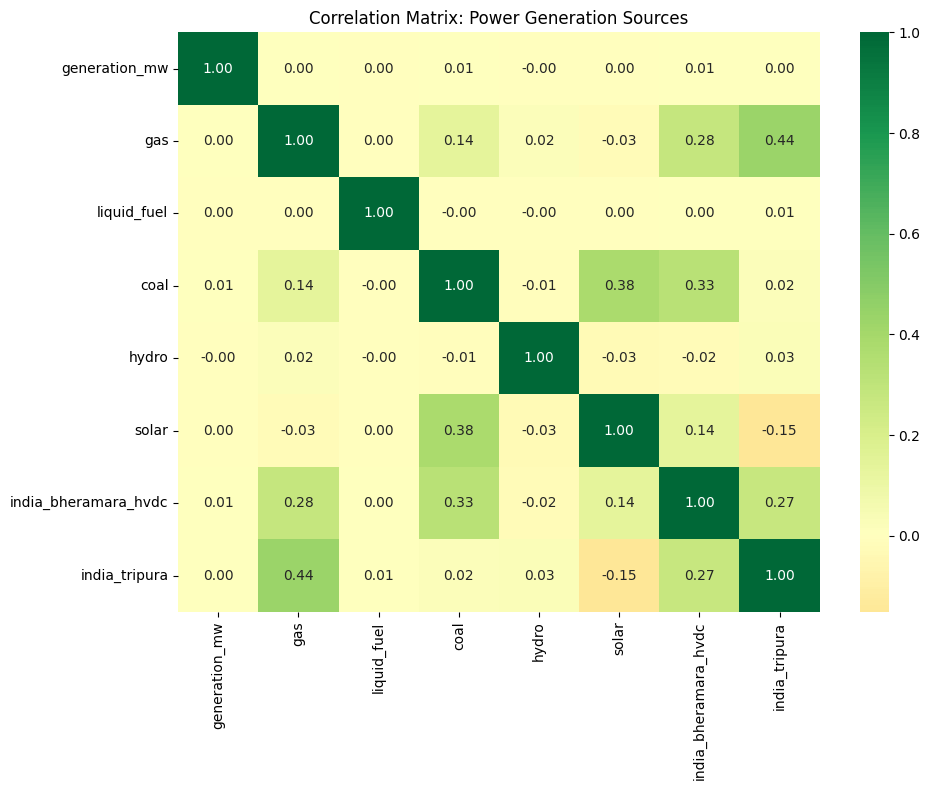

In [ ]:
# Define the generation-related columns
gen_cols = [
    'generation_mw', 'gas', 'liquid_fuel', 'coal', 
    'hydro', 'solar', 'india_bheramara_hvdc', 'india_tripura'
]

#Calculate the correlation matrix
#using .corr() to see how these variables move together
corr_matrix = demand[gen_cols].corr()

#Pull the specific correlation of 'generation_mw' against everything else
gen_correlation = corr_matrix[['generation_mw']].sort_values(by='generation_mw', ascending=False)

print("Correlation of sub-sources with Total Generation:")
print(gen_correlation)

# 4. Create a Heatmap for your defense slides
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title("Correlation Matrix: Power Generation Sources")
plt.tight_layout()
plt.show()

as observed from heatmap; the gwneration_mw has very high correlation with fuel sources like coal, etc and the generation being already summed in total generation, so dropping some cols like those

moreover, nepal and adani col has more than 70% of its data missing; so attempting to include them will create a lot of noise which further is not even required for next hour's production

In [88]:
demand = demand.drop(columns=['wind','india_adani','nepal','gas','liquid_fuel','coal','hydro','solar','india_bheramara_hvdc','load_shedding','india_tripura'])

In [89]:
demand.isnull().mean() * 100

datetime         0.0
demand_mw        0.0
generation_mw    0.0
dtype: float64

checking dataset before moving to other

In [90]:
demand.head(6)

,datetime,demand_mw,generation_mw
0,2015-04-19 00:00:00,4821.0,4821.0
1,2015-04-19 01:00:00,3612.0,3612.0
2,2015-04-19 02:00:00,3727.0,3727.0
3,2015-04-19 03:00:00,3632.0,3632.0
4,2015-04-19 04:00:00,3641.0,3641.0
5,2015-04-19 05:00:00,3283.0,3283.0


for econ dataset; the major problem is with its whole dataset as its in 'wide format', and each col from 1960s to 2025 has its own values pivoted for various indicators

In [91]:
econ.columns

Index(['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961',
       '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970',
       '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979',
       '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988',
       '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')

checking for datatypes too

In [92]:
econ.dtypes

Country Name       object
Indicator Name     object
Indicator Code     object
1960              float64
1961              float64
                   ...   
2021              float64
2022              float64
2023              float64
2024              float64
2025              float64
Length: 69, dtype: object

firstly, keeping only the indicator name and the year based cols and removing unnecessary data like country codes, etch etc

In [93]:
cols = ['Indicator Name'] + [col for col in econ.columns if col.isdigit()]
econ = econ[cols]


now converting the wide format dataset into rows n cols as such with each year as a row and each indicator as seperate feature col; here .melt()-separates yr cols n moves them as one-lables converted from text to integers and .pivot() taking values inside indicators and turning them into new col headers

In [94]:
econ_long = econ.melt(
    id_vars=['Indicator Name'],
    var_name='year',
    value_name='value'
)
econ_long['year'] = econ_long['year'].astype(int)
econ_final = econ_long.pivot(
    index='year',
    columns='Indicator Name',
    values='value'
).reset_index()



In [95]:
print(econ_final.columns)
econ_final.shape

Index(['year',
       'ARI treatment (% of children under 5 taken to a health provider)',
       'Access to clean fuels and technologies for cooking (% of population)',
       'Access to clean fuels and technologies for cooking, rural (% of rural population)',
       'Access to clean fuels and technologies for cooking, urban (% of urban population)',
       'Access to electricity (% of population)',
       'Access to electricity, rural (% of rural population)',
       'Access to electricity, urban (% of urban population)',
       'Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)',
       'Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)',
       ...
       'Women who believe a husband is justified in beating his wife (any of five reasons) (%)',
       'Women who believe a husband is justified in beating his wife when she argues with him (%)',
       'Wom

(66, 1517)

there is legit 66x1517 dataset here; different economic indicators cluters model; keeping urban population growth only as it allows coorelation with long term shifts with change in hourly electricity consumption

In [96]:
econ_sub = econ[econ['Indicator Name'] == 'Urban population growth (annual %)'].copy()
#taking cols for yr
year_cols = [col for col in econ.columns if str(col).isdigit()]
#turning the year columns into a single year column
econ_clean = econ_sub.melt(
    id_vars=['Indicator Name'], 
    value_vars=year_cols, 
    var_name='year', 
    value_name='urban_pop_growth'
)

#cleaning up data types so it merges perfectly with your main demand dataset
econ_clean['year'] = econ_clean['year'].astype(int)
econ_final = econ_clean[['year', 'urban_pop_growth']].dropna()

print(econ_final.head())

   year  urban_pop_growth
1  1961          5.994048
2  1962          6.413130
3  1963          6.340378
4  1964          6.375436
5  1965          6.446254


In [97]:
print(econ_final.columns)

Index(['year', 'urban_pop_growth'], dtype='object')


In [98]:
econ_final.head()

,year,urban_pop_growth
1,1961,5.994048
2,1962,6.413130
3,1963,6.340378
4,1964,6.375436
5,1965,6.446254


checking null values

In [99]:
econ_final.isnull().mean() * 100

year                0.0
urban_pop_growth    0.0
dtype: float64

In [100]:
demand.columns

Index(['datetime', 'demand_mw', 'generation_mw'], dtype='object')

as the three datasets are cleaned; merging them on year

In [101]:
demand['year'] = demand['datetime'].dt.year
df = pd.merge(demand, econ_final, on='year', how='left')
df = pd.merge(df, w1, on='datetime', how='left')


In [102]:
df.head()
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89101 entries, 0 to 89100
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          89101 non-null  datetime64[ns]
 1   demand_mw         89101 non-null  float64       
 2   generation_mw     89101 non-null  float64       
 3   year              89101 non-null  int32         
 4   urban_pop_growth  85080 non-null  float64       
 5   temp              89101 non-null  float64       
 6   humidity          89101 non-null  int64         
 7   apparent_temp     89101 non-null  float64       
 8   precipitation     89101 non-null  float64       
 9   dew_point         89101 non-null  float64       
 10  soil_temp         89101 non-null  float64       
 11  wind_dir          89101 non-null  int64         
 12  cloud_cover       89101 non-null  int64         
 13  sunshine          89101 non-null  float64       
dtypes: datetime64[ns](1), 

,datetime,demand_mw,generation_mw,year,urban_pop_growth,temp,humidity,apparent_temp,precipitation,dew_point,soil_temp,wind_dir,cloud_cover,sunshine
count,89101,89101.000000,8.910100e+04,89101.000000,85080.000000,89101.000000,89101.000000,89101.000000,89101.000000,89101.000000,89101.000000,89101.000000,89101.000000,89101.000000
mean,2020-05-18 06:00:00,8756.796099,9.395229e+03,2019.879519,2.069097,25.533344,77.387527,28.961260,0.217378,20.856628,26.731473,192.302151,51.352252,1372.538643
min,2015-04-19 00:00:00,6.000000,7.300000e+01,2015.000000,1.718184,8.400000,15.000000,6.600000,0.000000,2.500000,11.700000,1.000000,0.000000,0.000000
25%,2017-11-02 03:00:00,6740.000000,6.742000e+03,2017.000000,1.841763,22.800000,68.000000,24.500000,0.000000,16.300000,23.900000,135.000000,3.000000,0.000000
50%,2020-05-18 06:00:00,8352.000000,8.343000e+03,2020.000000,1.894721,26.500000,81.000000,30.900000,0.000000,23.000000,27.600000,178.000000,52.000000,0.000000
75%,2022-12-02 09:00:00,10571.000000,1.049900e+04,2022.000000,2.068846,28.900000,90.000000,33.800000,0.000000,25.200000,29.900000,276.000000,99.000000,3600.000000
max,2025-06-17 12:00:00,121000.000000,6.452650e+07,2025.000000,2.820159,40.800000,100.000000,45.600000,43.800000,28.600000,44.500000,360.000000,100.000000,3600.000000
std,NaN,2731.200933,2.161560e+05,2.958371,0.374502,5.027577,16.037562,6.892556,0.933715,5.161600,4.860220,93.532349,42.455515,1699.228624


In [103]:
df.columns

Index(['datetime', 'demand_mw', 'generation_mw', 'year', 'urban_pop_growth',
       'temp', 'humidity', 'apparent_temp', 'precipitation', 'dew_point',
       'soil_temp', 'wind_dir', 'cloud_cover', 'sunshine'],
      dtype='object')

dropping every column related to generation, imports, and load shedding as irl grid operators don't know until after they know the demand.
If we leave these in, the model will cheat. It will look at the total generation and use it to perfectly guess the demand (since Generation ≈ Demand + Losses).

In [104]:
leakage_cols = [
    'generation_mw', 
    'load_shedding', 
    'gas', 
    'liquid_fuel', 
    'coal', 
    'hydro', 
    'solar', 
    'india_bheramara_hvdc', 
    'india_tripura'
]
df = df.drop(columns=[col for col in leakage_cols if col in df.columns])
if 'year' in df.columns:
    df = df.drop(columns=['year'])

df.columns.tolist()

['datetime',
 'demand_mw',
 'urban_pop_growth',
 'temp',
 'humidity',
 'apparent_temp',
 'precipitation',
 'dew_point',
 'soil_temp',
 'wind_dir',
 'cloud_cover',
 'sunshine']

In [105]:
df.isnull().mean() * 100
print(df.isnull().mean().sort_values(ascending=False) * 100)
df.duplicated(subset='datetime').sum()


urban_pop_growth    4.512856
datetime            0.000000
demand_mw           0.000000
temp                0.000000
humidity            0.000000
apparent_temp       0.000000
precipitation       0.000000
dew_point           0.000000
soil_temp           0.000000
wind_dir            0.000000
cloud_cover         0.000000
sunshine            0.000000
dtype: float64


np.int64(0)

In [106]:
df.head(9)

,datetime,demand_mw,urban_pop_growth,temp,humidity,apparent_temp,precipitation,dew_point,soil_temp,wind_dir,cloud_cover,sunshine
0,2015-04-19 00:00:00,4821.0,2.068846,25.7,87,29.6,0.0,23.5,26.7,188,9,0.00
1,2015-04-19 01:00:00,3612.0,2.068846,25.3,88,30.0,0.0,23.2,26.4,151,26,0.00
2,2015-04-19 02:00:00,3727.0,2.068846,24.9,90,29.6,0.0,23.2,26.1,152,32,0.00
3,2015-04-19 03:00:00,3632.0,2.068846,25.0,90,29.3,0.0,23.3,26.1,171,30,0.00
4,2015-04-19 04:00:00,3641.0,2.068846,25.2,91,30.3,0.0,23.5,26.0,184,67,0.00
5,2015-04-19 05:00:00,3283.0,2.068846,24.9,92,30.2,0.0,23.6,25.9,114,78,0.00
6,2015-04-19 06:00:00,3444.0,2.068846,24.3,96,28.9,1.1,23.6,25.9,80,100,0.00
7,2015-04-19 07:00:00,3592.0,2.068846,24.0,97,28.2,4.6,23.5,26.5,94,97,2201.58
8,2015-04-19 08:00:00,4049.0,2.068846,24.2,96,27.9,2.4,23.5,26.5,135,92,724.65


In [107]:
df.columns

Index(['datetime', 'demand_mw', 'urban_pop_growth', 'temp', 'humidity',
       'apparent_temp', 'precipitation', 'dew_point', 'soil_temp', 'wind_dir',
       'cloud_cover', 'sunshine'],
      dtype='object')

several features that are essentially saying the exact same thing (Multicollinearity), and others that are just adding noise.

checking with correlation n graphs

In [108]:
df.corr()['demand_mw'].sort_values()


wind_dir           -0.094267
humidity           -0.081523
precipitation      -0.026071
sunshine            0.002754
cloud_cover         0.159610
dew_point           0.370382
urban_pop_growth    0.381967
temp                0.460748
apparent_temp       0.467256
soil_temp           0.482668
datetime            0.673267
demand_mw           1.000000
Name: demand_mw, dtype: float64

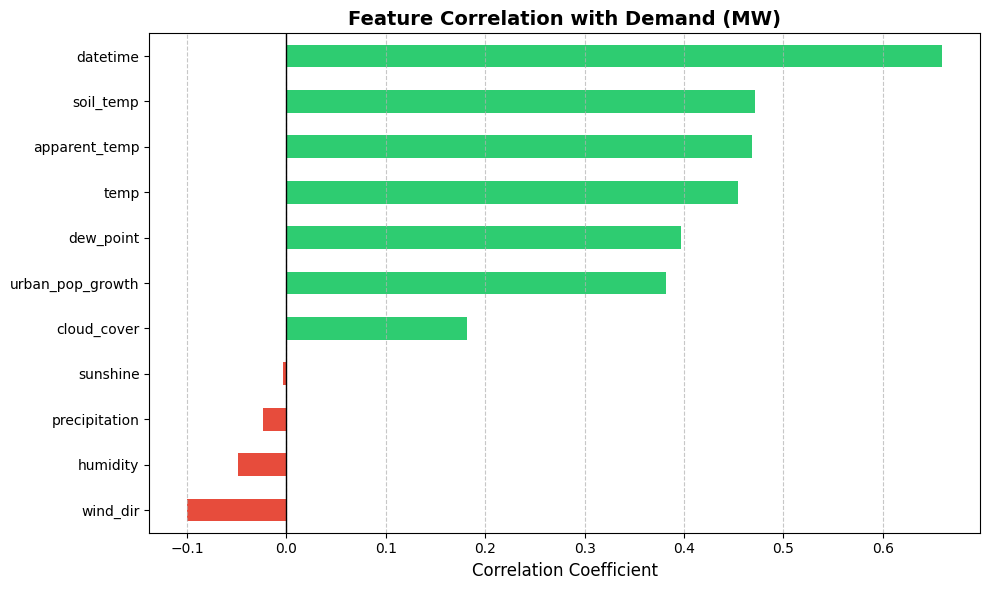

In [109]:
# 1. Create the correlation data based on your results
data = {
    'wind_dir': -0.100143,
    'humidity': -0.048412,
    'precipitation': -0.023771,
    'sunshine': -0.003566,
    'cloud_cover': 0.181602,
    'urban_pop_growth': 0.381967,
    'dew_point': 0.396752,
    'temp': 0.454913,
    'apparent_temp': 0.468132,
    'soil_temp': 0.471944,
    'datetime': 0.659975
}

# 2. Convert to a Series and sort it
corr_series = pd.Series(data).sort_values()

# 3. Plotting
plt.figure(figsize=(10, 6))
# Green for positive, Red for negative
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_series]

corr_series.plot(kind='barh', color=colors)

plt.title('Feature Correlation with Demand (MW)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Adds a center line at 0
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

removing variables like 'sunshine' and 'precipitation' which showed near-zero linear relationship with demand, thereby reducing model complexity and preventing overfitting

In [110]:
# Drop redundant and low-correlation noise
to_drop = [ 
    'temp', 'soil_temp',           # Redundant with apparent_temp
    'sunshine', 'precipitation',   # Near-zero correlation (noise)
    'humidity',                    # Low correlation (use your temp_humidity interaction instead)
    'wind_dir'                     # Weak correlation (-0.10)
]

f = [col for col in df.columns if col not in to_drop]
df = df[f]

In [111]:
df.columns

Index(['datetime', 'demand_mw', 'urban_pop_growth', 'apparent_temp',
       'dew_point', 'cloud_cover'],
      dtype='object')

In [112]:
df = df.dropna()

spikes

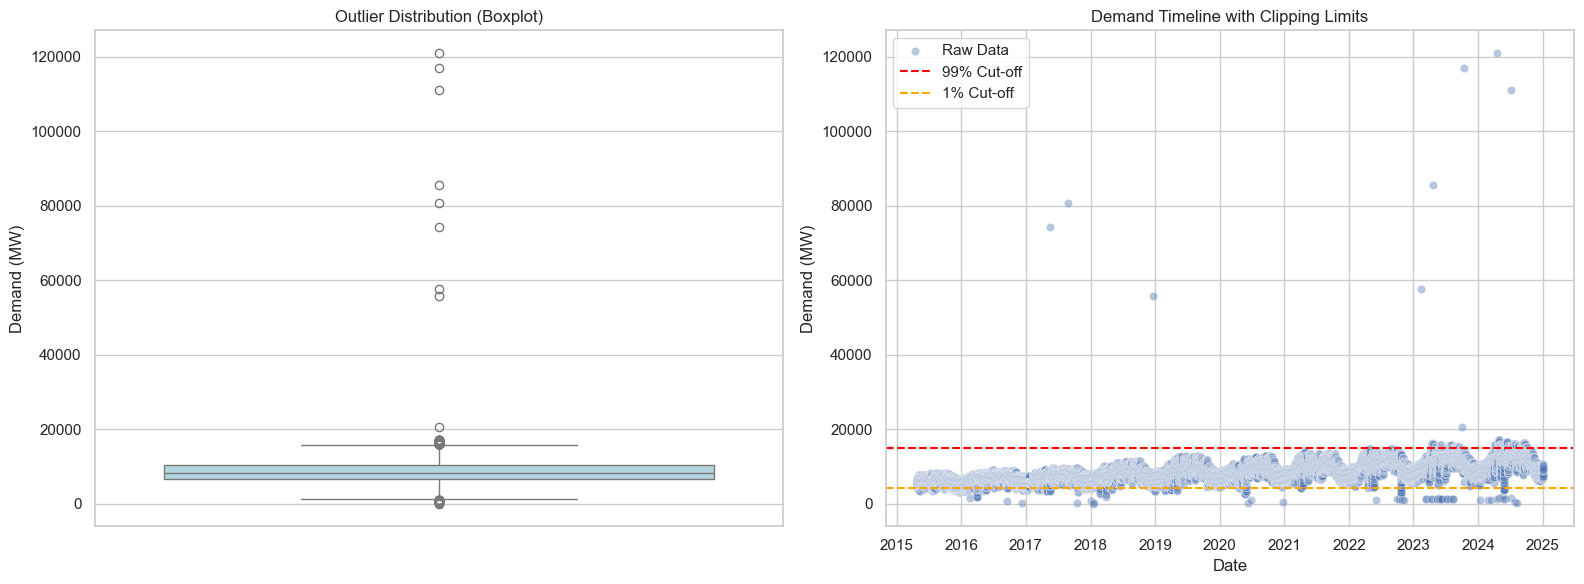

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

upper_limit = df['demand_mw'].quantile(0.99)
lower_limit = df['demand_mw'].quantile(0.01)
# Making a nice side-by-side plot
plt.figure(figsize=(16, 6))

#Boxplot to show the outliers
plt.subplot(1, 2, 1)
sns.boxplot(y=df['demand_mw'], color='lightblue')
plt.title('Outlier Distribution (Boxplot)')
plt.ylabel('Demand (MW)')

#Scatterplot to show the timeline
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['datetime'], y=df['demand_mw'], alpha=0.4, label='Raw Data')
# Drawing the lines where we clipped the data
plt.axhline(y=upper_limit, color='red', linestyle='--', label='99% Cut-off')
plt.axhline(y=lower_limit, color='orange', linestyle='--', label='1% Cut-off')

plt.title('Demand Timeline with Clipping Limits')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()

plt.tight_layout()
plt.show()

In [114]:
#capping extreme values to handle undocumented spikes
upper_limit = df['demand_mw'].quantile(0.99)
lower_limit = df['demand_mw'].quantile(0.01)

#creating a clean version of the demand column
df['demand_clean'] = np.clip(df['demand_mw'], lower_limit, upper_limit)

df['target_next_hour'] = df['demand_clean'].shift(-1)
df['lag_current_hour'] = df['demand_clean']
df['lag_1_hour_ago'] = df['demand_clean'].shift(1)
#24 hrs ago relative to the target
df['lag_24_hours_ago'] = df['demand_clean'].shift(23) 
#7 days ago
df['lag_1_week_ago'] = df['demand_clean'].shift(167)  
#basic rolling averages to smooth out noise
df['rolling_mean_6h'] = df['demand_clean'].rolling(6).mean()
df['rolling_mean_24h'] = df['demand_clean'].rolling(24).mean()
#extracting simple time features
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_evening_peak'] = df['hour'].isin([17,18,19,20,21,22,23]).astype(int)
df['apparent_temp_sq'] = df['apparent_temp'] ** 2
df['pop_heat_stress'] = df['apparent_temp_sq'] * df['urban_pop_growth']
df['muggy_idx'] = df['apparent_temp'] * df['dew_point']
#weather non-linearity
if 'temp' in df.columns:
    df['temp_squared'] = df['temp'] ** 2
#cylindrical mappinf for wind directions
if 'wind_dir' in df.columns:
    df['wind_sin'] = np.sin(2 * np.pi * df['wind_dir']/360)
    df['wind_cos'] = np.cos(2 * np.pi * df['wind_dir']/360)
    df = df.drop(columns=['wind_dir'])

#droping rows that have NaN values because of the shifting
df = df.dropna().reset_index(drop=True)


In [115]:
df.columns

Index(['datetime', 'demand_mw', 'urban_pop_growth', 'apparent_temp',
       'dew_point', 'cloud_cover', 'demand_clean', 'target_next_hour',
       'lag_current_hour', 'lag_1_hour_ago', 'lag_24_hours_ago',
       'lag_1_week_ago', 'rolling_mean_6h', 'rolling_mean_24h', 'hour',
       'month', 'day_of_week', 'is_weekend', 'is_evening_peak',
       'apparent_temp_sq', 'pop_heat_stress', 'muggy_idx'],
      dtype='object')

model

linear regression

In [ ]:
#TRAIN / TEST SPLIT 
print("Splitting data chronologically (Train <= 2023, Test >= 2024)...")
split_date = '2024-01-01'

train_data = df[df['datetime'] < split_date]
test_data  = df[df['datetime'] >= split_date]

cols_to_drop = ['datetime', 'demand_mw', 'demand_clean', 'target_next_hour']

X_train = train_data.drop(columns=cols_to_drop)
y_train = train_data['target_next_hour']

X_test  = test_data.drop(columns=cols_to_drop)
y_test  = test_data['target_next_hour']

# Clean up column names 
X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in X_train.columns]
X_test.columns  = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in X_test.columns]


#MANUAL SCALING & LINEAR REGRESSION
print("Manually scaling features and training Linear Regression;")

#Initialize the scaler
scaler = StandardScaler()

#fitting on the training data, and transform it.
X_train_scaled = scaler.fit_transform(X_train)

#tranforming the test data. 
X_test_scaled = scaler.transform(X_test)

#Initialize and train the model on the scaled data
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("Evaluating using Linear Regression: ")

#Predict using the explicitly scaled test data
lr_predictions = lr_model.predict(X_test_scaled)

mspe_lr = np.mean(np.square((y_test.values - lr_predictions) / y_test.values))
mape_lr = mean_absolute_percentage_error(y_test, lr_predictions)
mae_lr  = mean_absolute_error(y_test, lr_predictions)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_predictions))
print("\nLINEAR REGRESSION TEST SCORES")
print(f" MSPE: {mspe_lr * 100:.5f} %") 
print(f" MAPE: {mape_lr * 100:.3f} %")
print(f" MAE:  {mae_lr:.2f} MW")
print(f" RMSE: {rmse_lr:.2f} MW")


Splitting data chronologically (Train <= 2023, Test >= 2024)...
Manually scaling features and training Linear Regression;
Evaluating using Linear Regression: 

LINEAR REGRESSION TEST SCORES
 MSPE: 0.75710 %
 MAPE: 3.223 %
 MAE:  325.01 MW
 RMSE: 576.91 MW


random forest regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

#TRAIN / TEST SPLIT 
split_date = '2024-01-01'

train_data = df[df['datetime'] < split_date]
test_data  = df[df['datetime'] >= split_date]

cols_to_drop = ['datetime', 'demand_mw', 'demand_clean', 'target_next_hour']

X_train = train_data.drop(columns=cols_to_drop)
y_train = train_data['target_next_hour']

X_test  = test_data.drop(columns=cols_to_drop)
y_test  = test_data['target_next_hour']

#Clean up column names 
X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in X_train.columns]
X_test.columns  = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in X_test.columns]


#RANDOM FOREST TRAINING
print("Training using Random Forest Regressor (here no scaling is done):")

#Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,       
    random_state=42,
    n_jobs=-1
)

#Fit directly on the raw, un-scaled training data
rf_model.fit(X_train, y_train)

#Predict on the raw test data
rf_predictions = rf_model.predict(X_test)

mspe_rf = np.mean(np.square((y_test.values - rf_predictions) / y_test.values))
mape_rf = mean_absolute_percentage_error(y_test, rf_predictions)
mae_rf  = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("\nRANDOM FOREST REGRESSOR TEST SCORES")
print(f" MSPE: {mspe_rf * 100:.5f} %") 
print(f" MAPE: {mape_rf * 100:.3f} %")
print(f" MAE:  {mae_rf:.2f} MW")
print(f" RMSE: {rmse_rf:.2f} MW")

feature_names = X_train.columns
importances = rf_model.feature_importances_

# Create a quick DataFrame to view what the forest relied on most
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Impactful Features (by Forest Importance):")
print(importance_df.head(5).to_string(index=False))

Training using Random Forest Regressor (here no scaling is done):

RANDOM FOREST REGRESSOR TEST SCORES
 MSPE: 0.64147 %
 MAPE: 2.730 %
 MAE:  279.20 MW
 RMSE: 485.69 MW

Top 5 Most Impactful Features (by Forest Importance):
         Feature  Importance
lag_current_hour    0.970061
lag_24_hours_ago    0.012124
            hour    0.009123
  lag_1_hour_ago    0.003441
 rolling_mean_6h    0.001884


lightbgm model

In [ ]:
#TRAIN / TEST SPLIT 
split_date = '2024-01-01'

train_data = df[df['datetime'] < split_date]
test_data  = df[df['datetime'] >= split_date]

cols_to_drop = ['datetime', 'demand_mw', 'demand_clean', 'target_next_hour']

X_train = train_data.drop(columns=cols_to_drop)
y_train = train_data['target_next_hour']

X_test  = test_data.drop(columns=cols_to_drop)
y_test  = test_data['target_next_hour']

# LightGBM hates special characters in column names, so we clean them up
X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in X_train.columns]
X_test.columns  = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in X_test.columns]

print("Training using LightGBM model:")

model = lgb.LGBMRegressor(
    objective='mape',       
    n_estimators=742,       
    learning_rate=0.03,     
    max_depth=8,            
    num_leaves=63,          
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

#Train on the raw y_train
model.fit(X_train, y_train)

#Predict directly in Megawatts
predictions = model.predict(X_test)

#Extract raw values to prevent index misalignment
y_true = y_test.values 

#Calculate Metrics
mspe = np.mean(np.square((y_true - predictions) / y_true))
mape = mean_absolute_percentage_error(y_true, predictions)
mae  = mean_absolute_error(y_true, predictions)
rmse = np.sqrt(mean_squared_error(y_true, predictions))

print("\nFINAL TEST SET SCORES")
print(f" MSPE: {mspe * 100:.5f} %") 
print(f" MAPE: {mape * 100:.3f} %")
print(f" MAE:  {mae:.2f} MW")
print(f" RMSE: {rmse:.2f} MW")


Training using LightGBM model:
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001240 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2945
[LightGBM] [Info] Number of data points in the train set: 76129, number of used features: 18
[LightGBM] [Info] Start training from score 7295.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

FINAL TEST SET SCORES
 MSPE: 0.58094 %
 MAPE: 2.029 %
 MAE:  204.76 MW
 RMSE: 413.90 MW


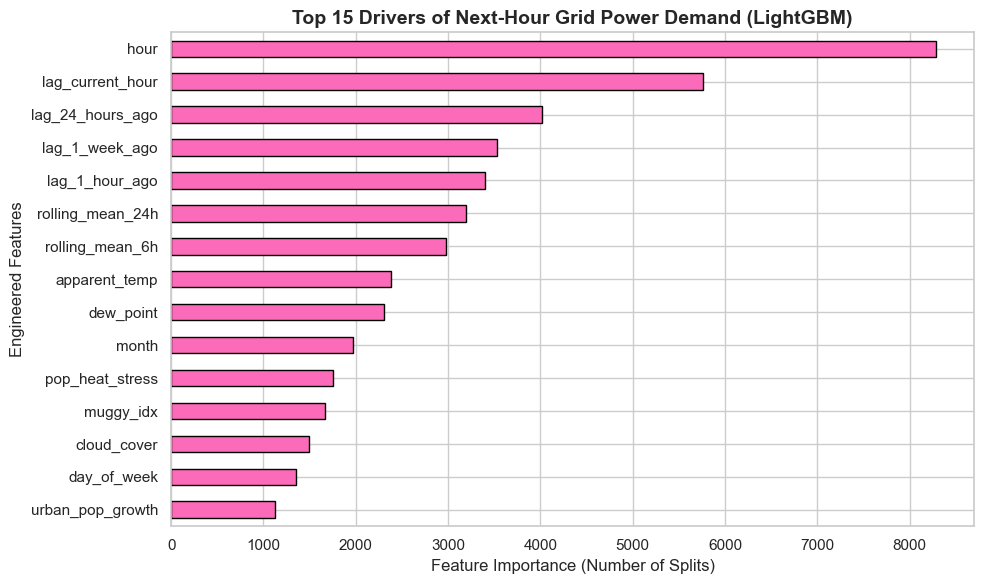

In [ ]:
# Plot Deliverable; Feature Importance
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_15 = importances.sort_values(ascending=True).tail(15)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
top_15.plot(kind='barh', color="#fc6aba", edgecolor='black')
plt.title('Top 15 Drivers of Next-Hour Grid Power Demand (LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance (Number of Splits)', fontsize=12)
plt.ylabel('Engineered Features', fontsize=12)
plt.tight_layout()
plt.show()

Thank you;
Anjali Pogulwad